# 05 Model Interpretation using SHAP and LIME

This notebook interprets the champion Gradient Boosting model selected in Notebook 4 using Explainable Artificial Intelligence (XAI) techniques.

The objectives are to:

- load the trained champion model
- explain global feature importance using SHAP
- explain individual customer predictions using SHAP
- generate local explanations using LIME
- compare SHAP and LIME explanations
- translate model explanations into business insights

Unlike traditional evaluation metrics, explainability techniques help reveal why a model makes specific predictions, increasing transparency and supporting more informed business decision-making.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import shap
import lime
import lime.lime_tabular

pd.set_option("display.max_columns", None)
pd.set_option("display.width",120)

shap.initjs()

## 2. Load Champion Model

The Gradient Boosting model selected in Notebook 4 is loaded for interpretation.

In [2]:
champion_model = joblib.load(
    "../models/champion_model.pkl"
)

print(type(champion_model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


## 3. Load Validation Dataset

The original validation dataset is loaded to generate model explanations.

Unlike the balanced training dataset used during model development, explanations are generated using unseen validation observations to reflect real-world prediction behaviour.

In [4]:
X_valid = pd.read_csv(
    "../data/processed/X_valid.csv"
)

y_valid = pd.read_csv(
    "../data/processed/y_valid.csv"
).squeeze()

print(X_valid.shape)

(3039, 32)


## 4. Model Verification

Before generating explanations, the loaded model is verified by reproducing its predictive performance on the validation dataset.

This confirms that the correct champion model has been loaded and ensures that all subsequent explanations correspond to the evaluated model.

Because the reproduced ROC AUC matches the performance reported in Notebook 4, subsequent SHAP explanations can be interpreted with confidence as explanations of the validated champion model.

In [5]:
from sklearn.metrics import roc_auc_score

y_prob = champion_model.predict_proba(
    X_valid
)[:,1]

roc_auc = roc_auc_score(
    y_valid,
    y_prob
)

print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9889


## 5. SHAP Overview

SHAP (SHapley Additive exPlanations) is an explainable AI technique based on cooperative game theory that explains how each feature contributes to a model's prediction.

Unlike traditional feature importance, SHAP quantifies both the magnitude and direction of each feature's contribution. Positive SHAP values increase the predicted probability of customer churn, whereas negative SHAP values decrease it.

Unlike traditional tree-based feature importance, SHAP provides consistent additive explanations at both the global and individual prediction levels, enabling a more transparent understanding of model behaviour.

This notebook first examines global explanations to identify the most influential predictors across the entire validation dataset before analysing individual customer predictions.

## 6. Initialise SHAP Explainer

The SHAP TreeExplainer is used because the selected champion model is a Gradient Boosting classifier.

TreeExplainer is specifically optimised for tree-based models and efficiently computes exact SHAP values while preserving consistency and local accuracy.

In [7]:
explainer = shap.TreeExplainer(champion_model)

shap_values = explainer.shap_values(X_valid)

print(type(shap_values))

<class 'numpy.ndarray'>


## 7. Global Feature Importance

Global SHAP feature importance measures the average contribution of each predictor across all observations.

Unlike traditional tree-based feature importance, SHAP values consider both the magnitude and direction of each feature's influence, providing a more robust interpretation of model behaviour.

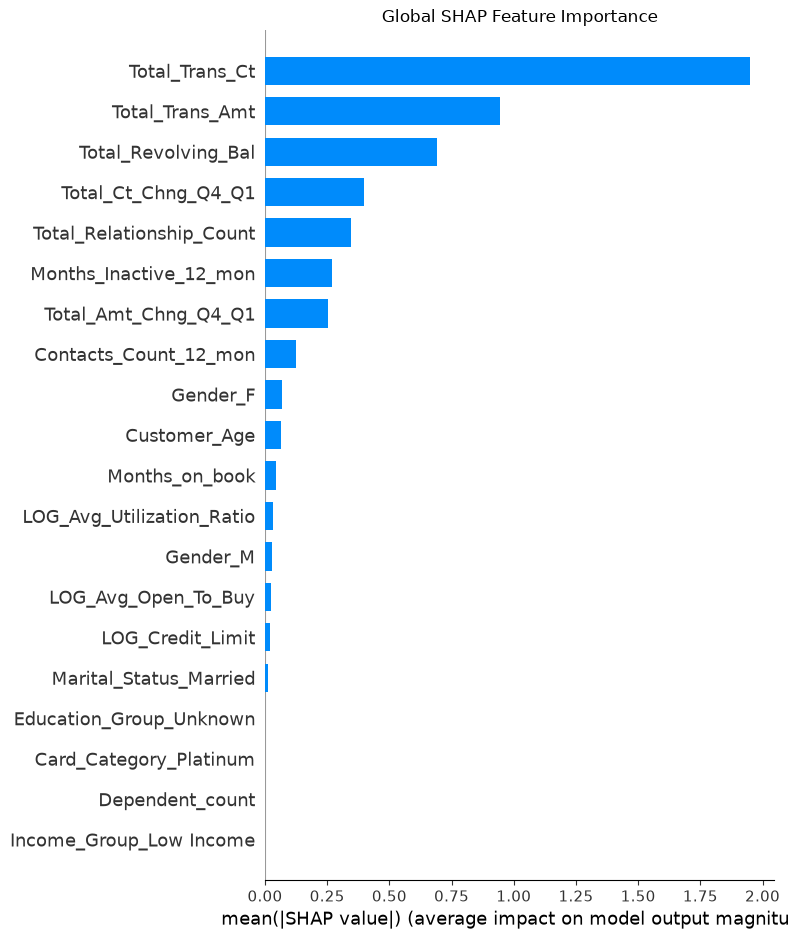

In [8]:
shap.summary_plot(
    shap_values,
    X_valid,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")

plt.tight_layout()

plt.show()

### Global SHAP Findings

The global SHAP feature importance results are highly consistent with the tree-based feature importance analysis presented in Notebook 4.

Across the validation dataset, **Total_Trans_Ct** was identified as the most influential predictor, followed by **Total_Trans_Amt**, **Total_Revolving_Bal**, **Total_Ct_Chng_Q4_Q1**, and **Total_Relationship_Count**. These variables collectively describe customer transaction behaviour, credit utilisation, and overall engagement with the bank.

The strong agreement between SHAP and the model-specific feature importance rankings increases confidence that these variables genuinely influence customer churn rather than reflecting biases of a particular explanation method.

Conversely, demographic variables such as gender, marital status, education, income group, and dependent count exhibited very small SHAP values, indicating that they contributed relatively little to the model's overall predictions.

Overall, the global SHAP analysis reinforces the earlier conclusion that customer behavioural characteristics are substantially more informative than demographic attributes for predicting customer attrition.


## 8. SHAP Summary Plot

The SHAP summary plot visualises both the importance and direction of feature effects across all validation observations.

Each point represents an individual customer.

- Red points indicate higher feature values.
- Blue points indicate lower feature values.

The horizontal position corresponds to the SHAP value, showing whether a feature increases or decreases the predicted probability of customer churn.

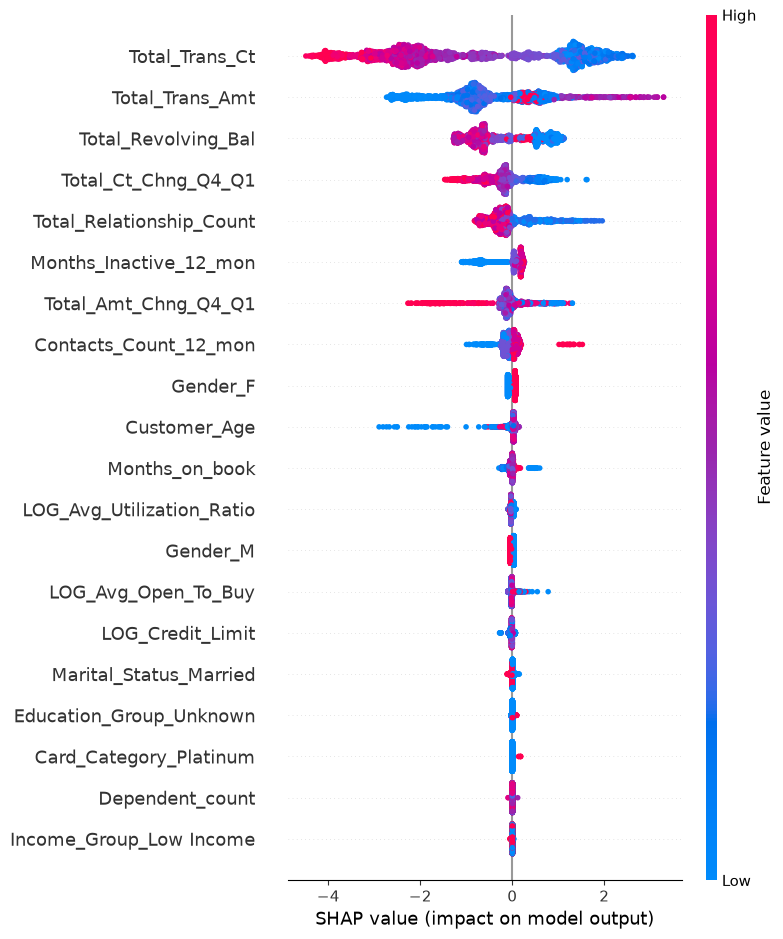

In [10]:
shap.summary_plot(
    shap_values,
    X_valid,
    show=False
)

plt.tight_layout()

plt.show()

### SHAP Summary Findings

The SHAP summary plot provides both the importance and directional influence of each feature on the predicted probability of customer churn.

Several clear behavioural patterns emerge from the model:

- Customers with **lower transaction counts (Total_Trans_Ct)** generally exhibit positive SHAP values, indicating an increased likelihood of churn, whereas customers with frequent transaction activity tend to have reduced churn risk.

- Similarly, **lower transaction amounts (Total_Trans_Amt)** contribute positively towards churn predictions, suggesting that reduced spending behaviour is a strong indicator of customer disengagement.

- **Total_Ct_Chng_Q4_Q1** demonstrates that declining transaction activity between quarters is associated with higher churn risk, while customers whose transaction activity remains stable or increases are less likely to leave.

- Customers with **fewer banking relationships (Total_Relationship_Count)** generally experience higher predicted churn probabilities, indicating that customers holding multiple banking products tend to exhibit greater loyalty.

- Behavioural variables consistently exhibit substantially larger SHAP values than demographic variables, indicating that recent customer engagement is considerably more influential than static customer characteristics when predicting customer churn.

The consistency between the two independent explanation methods increases confidence that the selected champion model has learned meaningful behavioural patterns rather than spurious relationships within the training data.

Overall, the SHAP summary plot indicates that the champion model primarily identifies churn through changes in customer behaviour rather than demographic differences, supporting the development of proactive retention strategies based on declining customer engagement.

### Comparison with Previous Feature Importance Analysis

The SHAP results closely align with the feature importance rankings obtained from the tree-based models in Notebook 4.

The five most influential predictors identified by SHAP—**Total_Trans_Ct**, **Total_Trans_Amt**, **Total_Revolving_Bal**, **Total_Ct_Chng_Q4_Q1**, and **Total_Relationship_Count**—were also consistently ranked among the most important variables by the Decision Tree, Random Forest, and Gradient Boosting models.

This consistency provides additional confidence that customer transaction behaviour, relationship activity, and credit utilisation are robust predictors of customer churn regardless of the explanation technique employed.

The agreement between SHAP and the tree-based feature importance analysis strengthens confidence in the robustness and reliability of the selected champion model.

## 9. Local Prediction using SHAP

While the previous sections explained the overall behaviour of the champion model, SHAP can also explain predictions for individual customers.

A local explanation decomposes a single prediction into feature-level contributions, illustrating how each customer characteristic increases or decreases the predicted probability of churn.

This enables analysts to understand not only whether a customer is likely to churn, but also the key behavioural factors driving that prediction.

In [11]:
prediction_df = pd.DataFrame({
    "Actual": y_valid,
    "Predicted Probability": champion_model.predict_proba(X_valid)[:,1]
})

prediction_df = prediction_df.sort_values(
    "Predicted Probability",
    ascending=False
)

prediction_df.head()

,Actual,Predicted Probability
2054,1,0.996674
1887,1,0.996355
234,1,0.996137
1610,1,0.995591
2121,1,0.995486


In [12]:
customer_index = prediction_df.index[0]

customer_index

np.int64(2054)

### Selected Customer

To demonstrate local model interpretability, the highest predicted probability of customer churn is selected.

This provides a realistic example of how SHAP explains an individual high-risk prediction and highlights the behavioural factors that most strongly influence the model's decision.

In [16]:
customer = X_valid.loc[[customer_index]]

selected_customer = pd.DataFrame({
    "Feature": customer.columns,
    "Value": customer.iloc[0].values
})

selected_customer


,Feature,Value
0,Customer_Age,39
1,Dependent_count,1
2,Months_on_book,36
3,Total_Relationship_Count,1
4,Months_Inactive_12_mon,2
5,Contacts_Count_12_mon,3
6,Total_Revolving_Bal,0
7,Total_Amt_Chng_Q4_Q1,0.393
8,Total_Trans_Amt,1998
9,Total_Trans_Ct,36


The customer's feature values are presented above to provide context before interpreting the SHAP explanation.

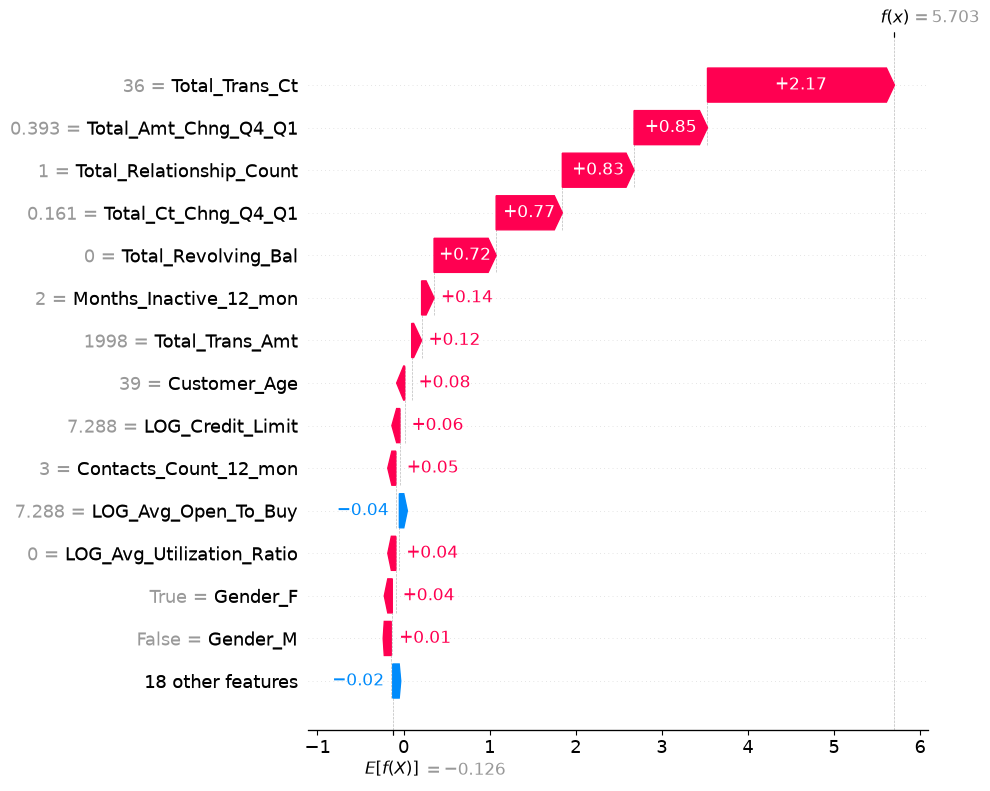

In [17]:
explanation = explainer(customer)

shap.plots.waterfall(
    explanation[0],
    max_display=15
)

### Local SHAP Findings

The SHAP waterfall plot explains why the selected customer was assigned an exceptionally high probability of churn.

The model's baseline prediction is progressively adjusted by each feature until the final prediction is obtained. Features shown in red increase the predicted likelihood of churn, whereas blue features reduce it.

For this customer, several behavioural characteristics strongly increased the predicted churn risk:

- **Low transaction count (Total_Trans_Ct = 36)** contributed the largest positive SHAP value, indicating substantially lower card usage than customers who typically remain with the bank.
- **Low transaction amount (Total_Trans_Amt = 1998)** further increased the predicted churn probability, suggesting declining customer spending.
- **Only one banking relationship (Total_Relationship_Count = 1)** indicates limited product engagement and contributed significantly towards the churn prediction.
- **Low transaction count change (Total_Ct_Chng_Q4_Q1 = 0.161)** suggests declining customer activity across quarters, further increasing churn risk.
- **Zero revolving balance** also contributed positively to the prediction, reflecting limited utilisation of the customer's available credit.

The largest local contributor (Total_Trans_Ct) is also the most influential global predictor identified in the previous SHAP analyses, demonstrating consistency between global and local model explanations.

Only a small number of features reduced the predicted probability of churn, and their combined effect was insufficient to offset the strong behavioural indicators of customer disengagement.

Overall, the waterfall plot demonstrates how multiple behavioural risk factors collectively led the champion model to classify this customer as having an exceptionally high likelihood of churn.

## 10. LIME Overview

While SHAP provides theoretically consistent explanations based on Shapley values, Local Interpretable Model-agnostic Explanations (LIME) adopts a different approach by approximating the behaviour of a complex model with an interpretable surrogate model in the neighbourhood of a single prediction.

Unlike SHAP, which provides both global and local explanations, LIME focuses exclusively on explaining individual predictions. By perturbing the selected observation and observing how the model responds, LIME identifies the features that most strongly influence a specific prediction.

To facilitate a meaningful comparison, the same high-risk customer analysed using SHAP is explained using LIME in the following sections.

## 11. Initialise LIME Explainer

The LIME Tabular Explainer is initialised using the original validation dataset. Continuous variables are discretised to improve interpretability, while categorical variables remain represented through the one-hot encoded features created during preprocessing.

The explainer uses the champion Gradient Boosting model to generate local explanations for the selected customer.

In [21]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_valid.values,
    feature_names=X_valid.columns.tolist(),
    class_names=["Existing Customer", "Attrited Customer"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

## 12. Local Prediction using LIME

Using the same customer analysed with SHAP, LIME generates a local explanation by approximating the Gradient Boosting model with an interpretable linear model around the selected observation.

This allows the most influential features contributing to the customer's predicted churn risk to be identified and compared with the SHAP explanation.

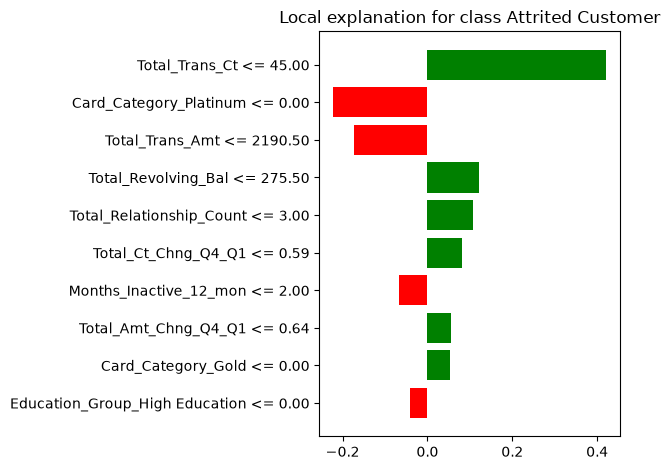

In [26]:
customer = X_valid.loc[[customer_index]]

def predict_proba_with_columns(x):
    x = pd.DataFrame(
        x,
        columns=X_valid.columns
    )
    return champion_model.predict_proba(x)

lime_exp = lime_explainer.explain_instance(
    customer.iloc[0].values,
    predict_proba_with_columns,
    num_features=10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

### LIME Findings

The LIME explanation provides an interpretable approximation of the champion model's behaviour within the local neighbourhood of the selected customer.

Consistent with the SHAP explanation, the customer's **low transaction count**, **low transaction amount**, **limited banking relationship**, and **low transaction count change** were identified as the primary factors contributing to the predicted churn risk.

Unlike SHAP, which quantifies the exact contribution of each feature using Shapley values, LIME explains the prediction through a locally fitted surrogate model. Consequently, the relative ordering and contribution of individual variables may differ slightly from the SHAP explanation.

Nevertheless, both explanation techniques consistently identify declining customer engagement and reduced transaction activity as the dominant behavioural indicators of churn for this customer, increasing confidence in the robustness of the champion model's prediction.

## 13. Comparison of SHAP and LIME

Both SHAP and LIME were applied to explain the same high-risk customer prediction generated by the champion Gradient Boosting model.

Although both techniques aim to improve model interpretability, they adopt different explanation strategies. SHAP computes theoretically consistent feature contributions based on cooperative game theory, whereas LIME approximates the model locally using an interpretable surrogate model.

Comparing both methods provides additional confidence that the identified churn drivers are robust rather than artefacts of a single explanation technique.

In [29]:
comparison = pd.DataFrame({
    "Aspect":[
        "Explanation Scope",
        "Methodology",
        "Model Specific",
        "Theoretical Guarantees",
        "Interpretation"
    ],
    "SHAP":[
        "Global & Local",
        "Shapley Values",
        "Tree-specific optimisation",
        "High",
        "Exact feature contribution"
    ],
    "LIME":[
        "Local Only",
        "Local surrogate model",
        "Model-agnostic",
        "Approximate",
        "Local approximation"
    ]
})

comparison

,Aspect,SHAP,LIME
0,Explanation Scope,Global & Local,Local Only
1,Methodology,Shapley Values,Local surrogate model
2,Model Specific,Tree-specific optimisation,Model-agnostic
3,Theoretical Guarantees,High,Approximate
4,Interpretation,Exact feature contribution,Local approximation


### Comparison Findings

The strong agreement between SHAP and LIME is particularly encouraging because the two methods rely on fundamentally different explanation mechanisms.

Despite using different explanation methodologies, SHAP and LIME identified highly similar behavioural characteristics as the primary drivers of churn for the selected customer.

Both methods consistently highlighted:

- low transaction count
- low transaction amount
- limited banking relationships
- declining customer activity

The agreement between the two independent explanation techniques strengthens confidence that the identified behavioural factors genuinely influenced the champion model's prediction rather than reflecting explanation-specific artefacts.

Overall, SHAP provides a more comprehensive explanation by supporting both global and local interpretability, whereas LIME offers an intuitive local approximation that is easier to communicate to non-technical stakeholders.

## 14. Business Insights

The explainability analyses consistently demonstrate that behavioural variables are substantially more informative than demographic characteristics for identifying customers at risk of churn.

Customers exhibiting declining transaction frequency, reduced spending behaviour, limited product relationships, and decreasing engagement over time should therefore be prioritised for proactive retention initiatives.

These findings suggest that customer behavioural monitoring should be incorporated into early warning systems so that intervention can occur before customers disengage completely.

Rather than relying on static demographic segmentation, banks can leverage these behavioural indicators to identify high-risk customers earlier and implement targeted retention strategies such as personalised engagement campaigns, product recommendations, and loyalty incentives.

The consistency between global SHAP analysis, local SHAP explanations, and LIME explanations provides confidence that these recommendations are supported by multiple independent explainability techniques.

## 15. Summary

This notebook interpreted the champion Gradient Boosting model using two complementary explainable AI techniques: SHAP and LIME.

Global SHAP analysis identified customer transaction behaviour and relationship activity as the strongest predictors of churn across the validation dataset. Local SHAP and LIME explanations further demonstrated how these behavioural characteristics collectively contributed to an individual customer's exceptionally high predicted churn risk.

The strong agreement between SHAP, LIME, and the feature importance analysis presented in Notebook 4 increases confidence that the selected champion model has learned meaningful behavioural patterns rather than spurious relationships.

Together, SHAP and LIME improve model transparency, strengthen stakeholder trust, and translate complex machine learning predictions into actionable customer retention strategies.